In [2]:
import pandas as pd
from pathlib import Path

dfs = []

for f in Path("..", "..", "synergy-release-datasets").iterdir():
    if f.is_dir() and not f.name.startswith("."):
        df = pd.read_csv(f / "labels.csv")
        df["dataset_id"] = f.name   # add the column
        dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)

In [3]:
print("Total records:", len(big_df))
print("Unique datasets:", big_df["dataset_id"].nunique())
print("Unique languages:", big_df["language"].nunique())
#Inclusion stats
print("Mean inclusion percentage AB:", round(big_df["label_abstract_included"].mean() * 100, 3), "%")
print("Mean inclusion percentage FT:", round(big_df["label_included"].mean() * 100, 3), "%")
#Open-access
print("Mean open-access percentage:", round(big_df["is_open_access"].mean() * 100, 3), "%")
#Text availability
print("Mean abstract availability percentage:", round(big_df["abstract"].notna().mean() * 100, 3), "%")
print("Mean title availability percentage:", round(big_df["title"].notna().mean() * 100, 3), "%")
#OA by language
#oa_by_language = big_df.groupby("language")["is_open_access"].mean() * 100
#print("\nOpen-access percentage by language:")
#print(oa_by_language)
#Label inclusion by language
#label_by_language = big_df.groupby("language")["label_included"].mean() * 100
#print("\nLabel inclusion percentage by language:")
#print(label_by_language)
#Label inclusion by OA status
label_by_oa = big_df.groupby("oa_status")["label_included"].mean() * 100
print("\nLabel inclusion percentage by OA status:")
print(label_by_oa)
#Abstract coverage by dataset
abstract_coverage_by_dataset = big_df.groupby("dataset_id")["abstract"].apply(lambda x: x.notna().mean() * 100)
print("\nAbstract availability percentage by dataset:")
print(abstract_coverage_by_dataset)
#Labeled abstract coverage by dataset
labeled_abstract_coverage_by_dataset = big_df.groupby("dataset_id")["label_abstract_included"].mean() * 100
print("\nLabeled abstract inclusion percentage by dataset:")
print(labeled_abstract_coverage_by_dataset)
#Missing IDs
missing_ids = big_df[["doi", "pmid", "openalex_id"]].isna().mean() * 100
print("\nMissing IDs percentage:")
print(missing_ids)
#Abstract length stats (only for non-missing abstracts)
big_df["abstract_length"] = big_df["abstract"].dropna().apply(len)
abstract_length_stats = big_df["abstract_length"].agg(["mean", "median", "max"])
print("\nAbstract length stats (characters):")
print(abstract_length_stats)

Total records: 494793
Unique datasets: 120
Unique languages: 55
Mean inclusion percentage AB: 7.329 %
Mean inclusion percentage FT: 2.321 %
Mean open-access percentage: 35.805 %
Mean abstract availability percentage: 92.595 %
Mean title availability percentage: 99.988 %

Label inclusion percentage by OA status:
oa_status
bronze     2.346428
closed     2.151533
diamond    2.221093
gold       2.739504
green      2.722760
hybrid     3.158374
Name: label_included, dtype: float64

Abstract availability percentage by dataset:
dataset_id
Abgaz_2023                    90.450205
Adamo_2021                    99.093722
Ali_2024                      99.626168
Alunno_2020                   99.863667
Anmarkrud_2021               100.000000
                                ...    
van_Heugten_Breurkes_2022     98.303887
van_Hoorn_2020                98.788927
van_de_Schoot_2025            98.889948
van_der_Valk_2021             98.062016
van_der_Waal_2022             83.333333
Name: abstract, Length:

In [4]:
#Abstract length stats (only for non-missing abstracts)
big_df["abstract_length"] = big_df["abstract"].dropna().apply(lambda x: len(x.split()))
abstract_length_stats = big_df["abstract_length"].agg(["mean", "median", "max", "min", "count"])
print("\nAbstract length stats (characters):")
print(abstract_length_stats)


Abstract length stats (characters):
mean         223.703979
median       214.000000
max         8912.000000
min            1.000000
count     458153.000000
Name: abstract_length, dtype: float64


<Axes: >

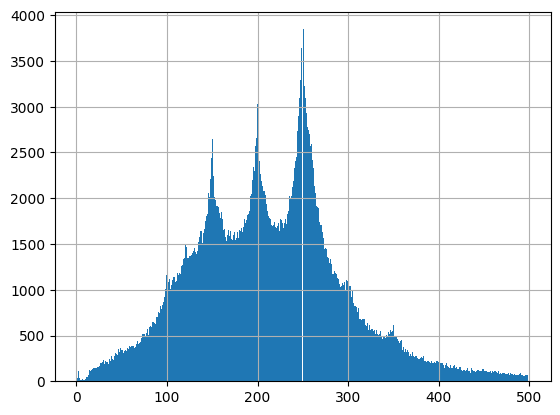

In [5]:
big_df[big_df["abstract_length"] < 500]["abstract_length"].hist(bins=500)

In [6]:
big_df[(big_df["abstract_length"] > 0) & (big_df["abstract_length"] < 20)]

,openalex_id,doi,pmid,label_included,label_abstract_included,title,abstract,is_open_access,oa_status,language,dataset_id,abstract_length
937,https://openalex.org/W1998017769,https://doi.org/10.1080/01621459.2000.10474338,NaN,0,NaN,Hierarchical Models: A Current Computational P...,(2000). Hierarchical Models: A Current Computa...,False,closed,en,Smid_2019,19.0
1119,https://openalex.org/W1602441541,https://doi.org/10.1002/0470036486.ch7,NaN,0,NaN,Mixed Regression Models with Autocorrelated Er...,This chapter contains sections titled: Introdu...,False,closed,en,Smid_2019,14.0
1392,https://openalex.org/W1771846642,NaN,NaN,0,NaN,Latent growth mixture modeling : a simulation ...,unknown accessibility,True,green,en,Smid_2019,2.0
1608,https://openalex.org/W2066860102,https://doi.org/10.1080/01621459.2000.10474333,NaN,0,NaN,The Bootstrap and Modern Statistics,(2000). The Bootstrap and Modern Statistics. J...,False,closed,en,Smid_2019,18.0
2678,https://openalex.org/W2033190934,https://doi.org/10.3402/ejpt.v6.27516,NaN,0,NaN,Using Bayesian statistics for modeling PTSD th...,No abstract available. (Published: 2 March 201...,True,gold,en,Smid_2019,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...
486886,https://openalex.org/W2003408006,https://doi.org/10.1188/04.onf.e56-e65,https://pubmed.ncbi.nlm.nih.gov/15897928,0,NaN,Psychospiritual well-being and symptom distres...,for this article also available on page 543 of...,False,closed,en,Hilfiker_2017,16.0
486946,https://openalex.org/W2801038256,https://doi.org/10.1007/s10549-018-4790-2,https://pubmed.ncbi.nlm.nih.gov/29693230,0,NaN,Impact of port site scar on perception of pati...,37th Annual Meeting of the American Society of...,False,closed,en,Hilfiker_2017,17.0
487037,https://openalex.org/W2027836000,https://doi.org/10.1191/0269216302pm597xx,https://pubmed.ncbi.nlm.nih.gov/12465705,1,NaN,A pilot study to evaluate the effect of reflex...,"In summary, patients in both groups generally ...",False,closed,en,Hilfiker_2017,17.0
488664,https://openalex.org/W2569484859,https://doi.org/10.1097/gme.0000000000000821,https://pubmed.ncbi.nlm.nih.gov/28072609,0,NaN,The impact of estrogen alone hormone therapy o...,Department of Obstetrics and Gynecology Massac...,False,closed,en,Hilfiker_2017,13.0


In [7]:
#Abstract length stats (only for non-missing abstracts)
big_df["abstract_length"] = big_df[big_df["is_open_access"] == 1]["abstract"].dropna().apply(lambda x: len(x.split()))
abstract_length_stats = big_df["abstract_length"].agg(["mean", "median", "max", "min", "count"])
print("\nAbstract length stats (characters):")
print(abstract_length_stats)


Abstract length stats (characters):
mean         248.889426
median       242.000000
max         8912.000000
min            1.000000
count     173793.000000
Name: abstract_length, dtype: float64


<Axes: >

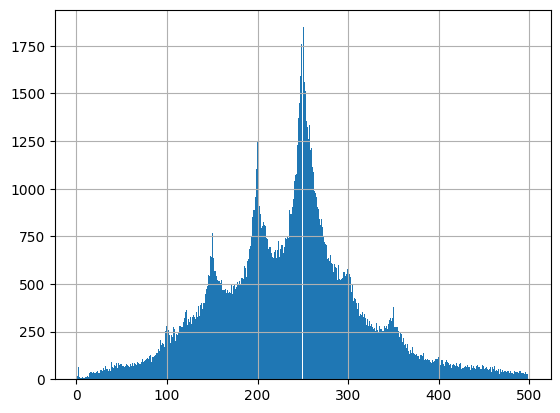

In [8]:
big_df[big_df["abstract_length"] < 500]["abstract_length"].hist(bins=500)

In [9]:
#roportion of label_included == 1 with title and abstract
label_ft = big_df[big_df["label_included"] == 1]
ft_with_title_and_abstract = (label_ft["title"].notna() & label_ft["abstract"].notna()).mean() * 100
print("\nPercentage of full-text inclusions with title and abstract:", round(ft_with_title_and_abstract, 3), "%")
#Proportion of label_abstract_included == 1 with title and abstract
label_ab = big_df[big_df["label_abstract_included"] == 1]
ab_with_title_and_abstract = (label_ab["title"].notna() & label_ab["abstract"].notna()).mean() * 100
print("Percentage of abstract-inclusions with title and abstract:", round(ab_with_title_and_abstract, 3), "%")


Percentage of full-text inclusions with title and abstract: 98.45 %
Percentage of abstract-inclusions with title and abstract: 96.536 %


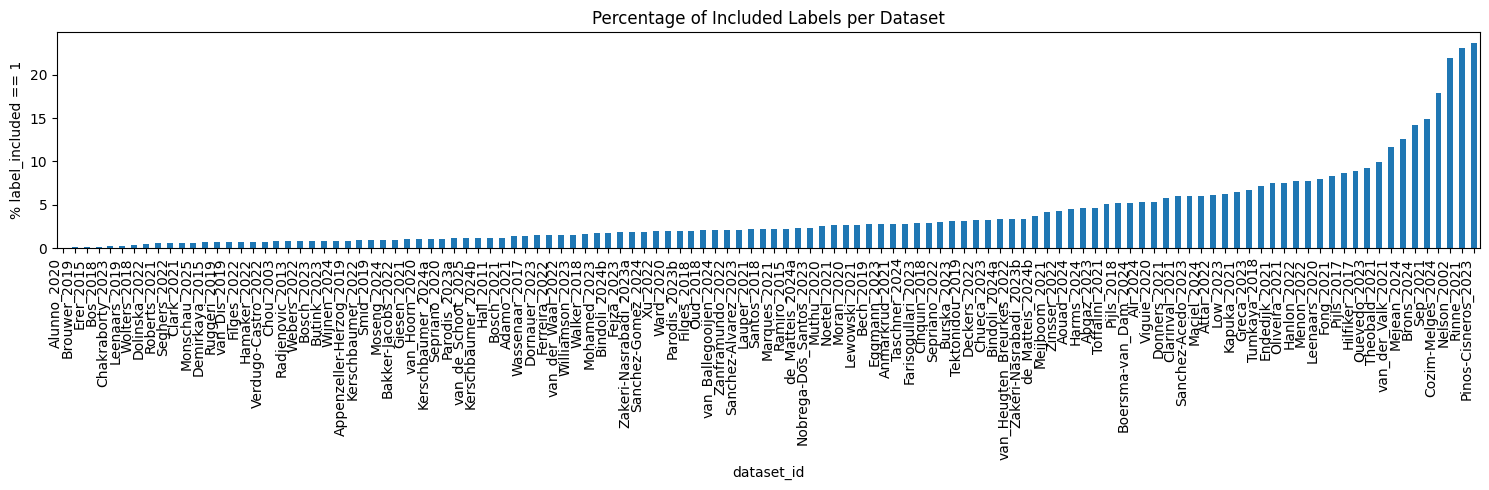

In [10]:
import matplotlib.pyplot as plt

# Compute percentages
pct_label = (
    big_df.groupby("dataset_id")["label_included"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(15, 5))
pct_label.plot(kind="bar")
plt.ylabel("% label_included == 1")
plt.title("Percentage of Included Labels per Dataset")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

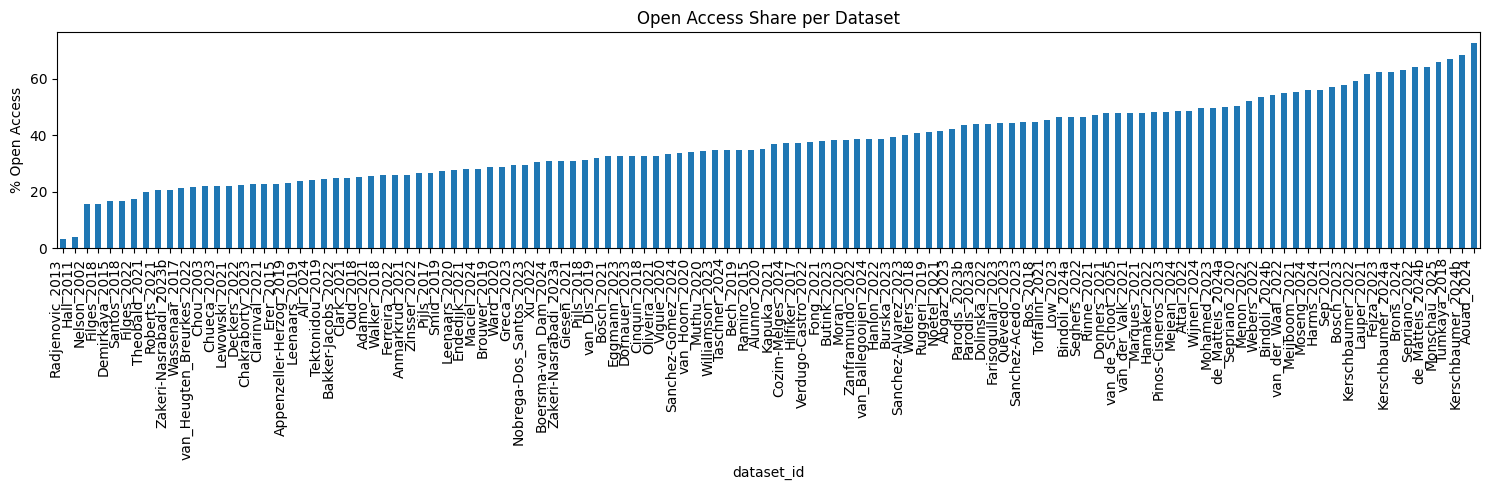

In [11]:
pct_oa = (
    big_df.groupby("dataset_id")["is_open_access"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(15, 5))
pct_oa.plot(kind="bar")
plt.ylabel("% Open Access")
plt.title("Open Access Share per Dataset")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

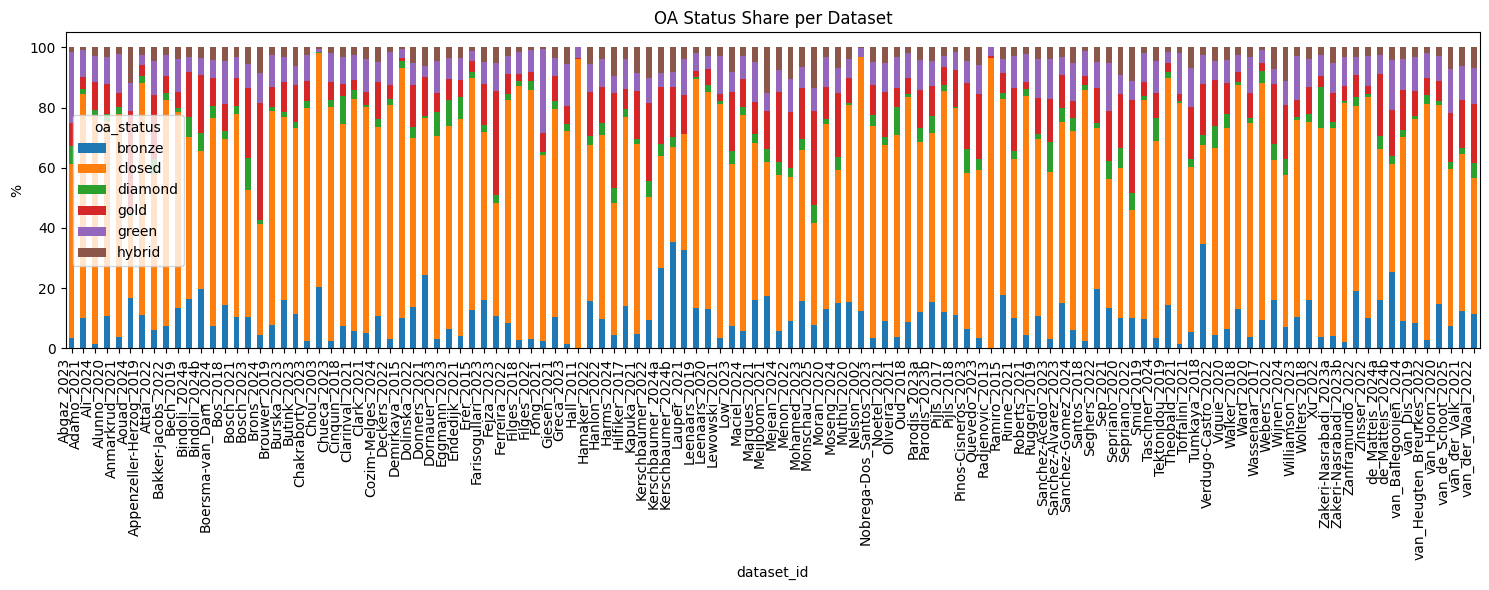

In [12]:
oa_counts = big_df.pivot_table(
    index="dataset_id",
    columns="oa_status",
    aggfunc="size",
    fill_value=0
)

oa_pct = oa_counts.div(oa_counts.sum(axis=1), axis=0).mul(100)

oa_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 6)
)

plt.ylabel("%")
plt.title("OA Status Share per Dataset")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

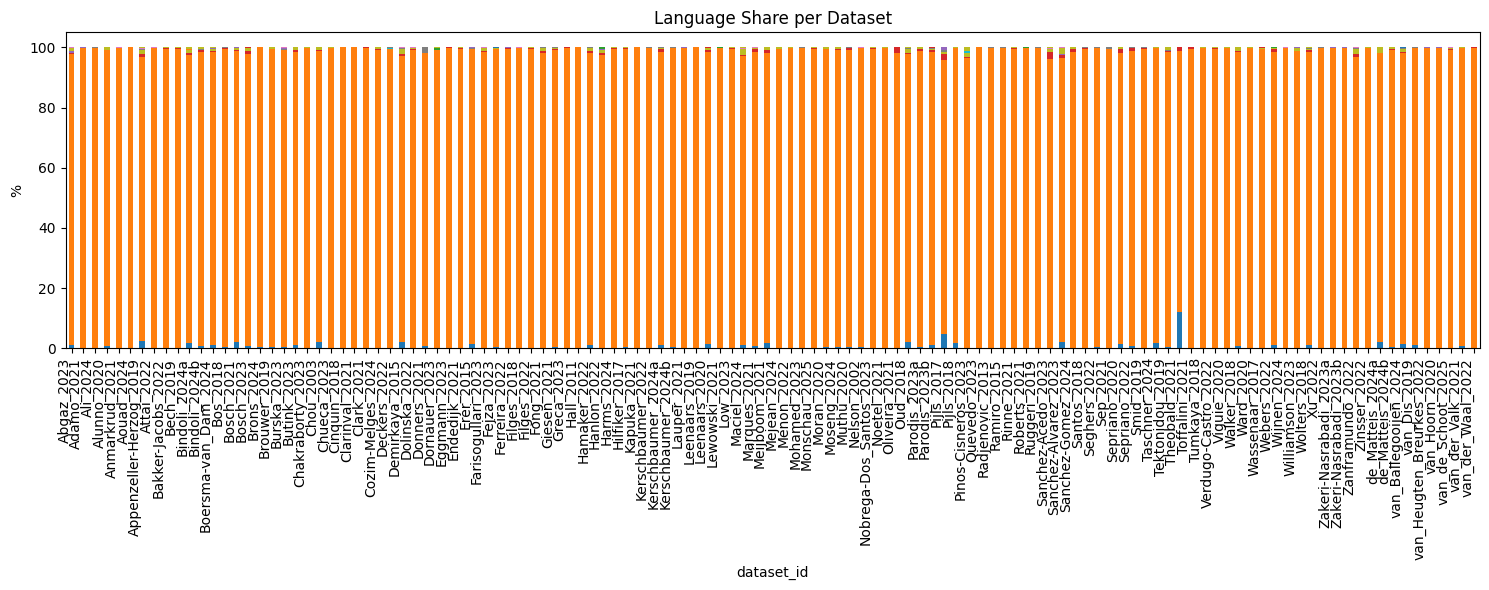

In [13]:
lang_counts = big_df.pivot_table(
    index="dataset_id",
    columns="language",
    aggfunc="size",
    fill_value=0
)


lang_pct = lang_counts.div(lang_counts.sum(axis=1), axis=0).mul(100)

lang_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 6),
    legend=False
)

plt.ylabel("%")
plt.title("Language Share per Dataset")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

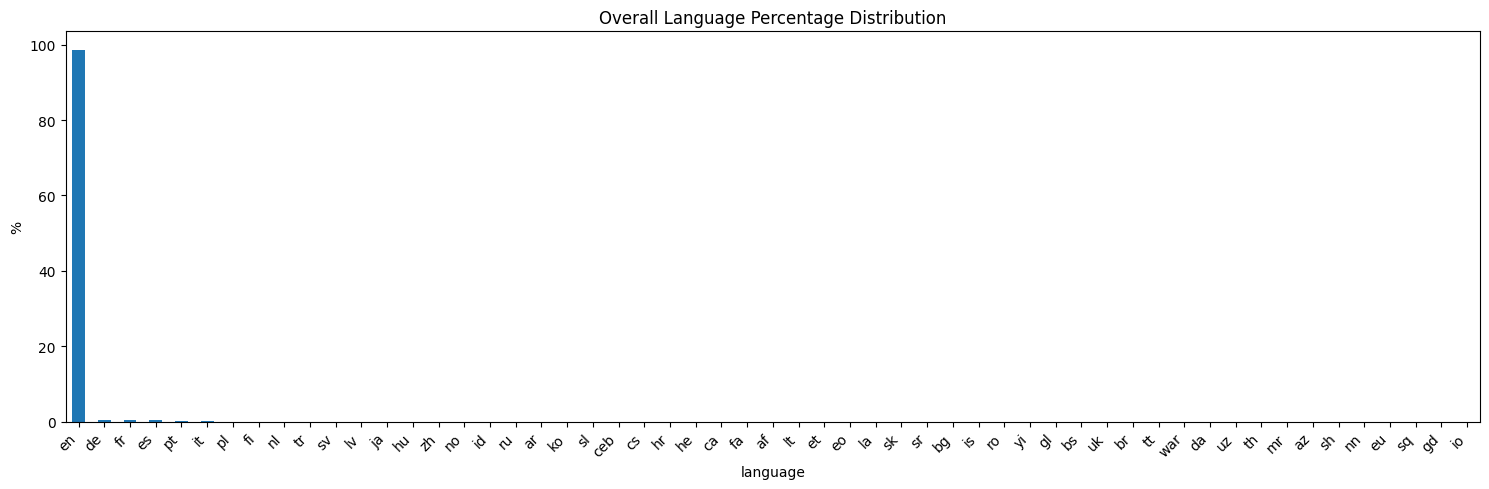

In [14]:
plt.figure(figsize=(15, 5))
(big_df["language"].value_counts(normalize=True) * 100).plot(kind="bar")

plt.ylabel("%")
plt.title("Overall Language Percentage Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

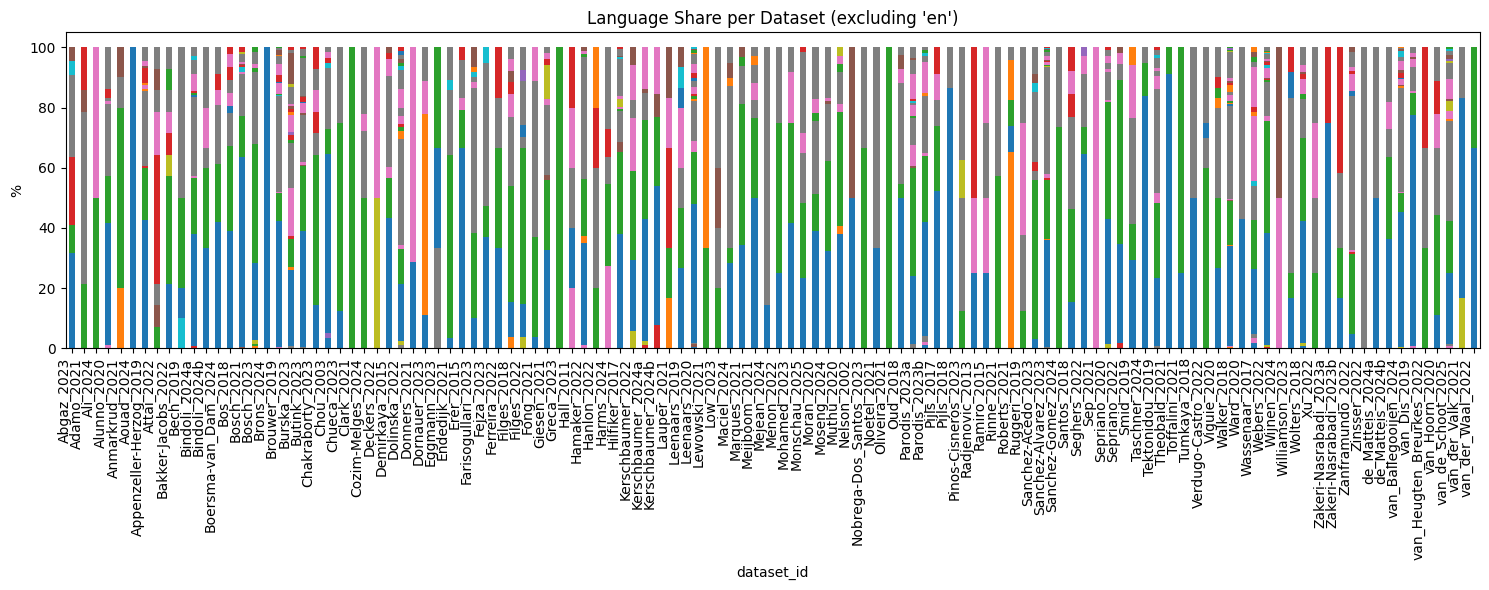

In [15]:
# Filter out English
df_no_en = big_df[big_df["language"] != "en"]

# Count languages per dataset
lang_counts_no_en = df_no_en.pivot_table(
    index="dataset_id",
    columns="language",
    aggfunc="size",
    fill_value=0
)

lang_pct_no_en = lang_counts_no_en.div(
    lang_counts_no_en.sum(axis=1), axis=0
).mul(100)

lang_pct_no_en.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 6),
    legend=False
)

plt.ylabel("%")
plt.title("Language Share per Dataset (excluding 'en')")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

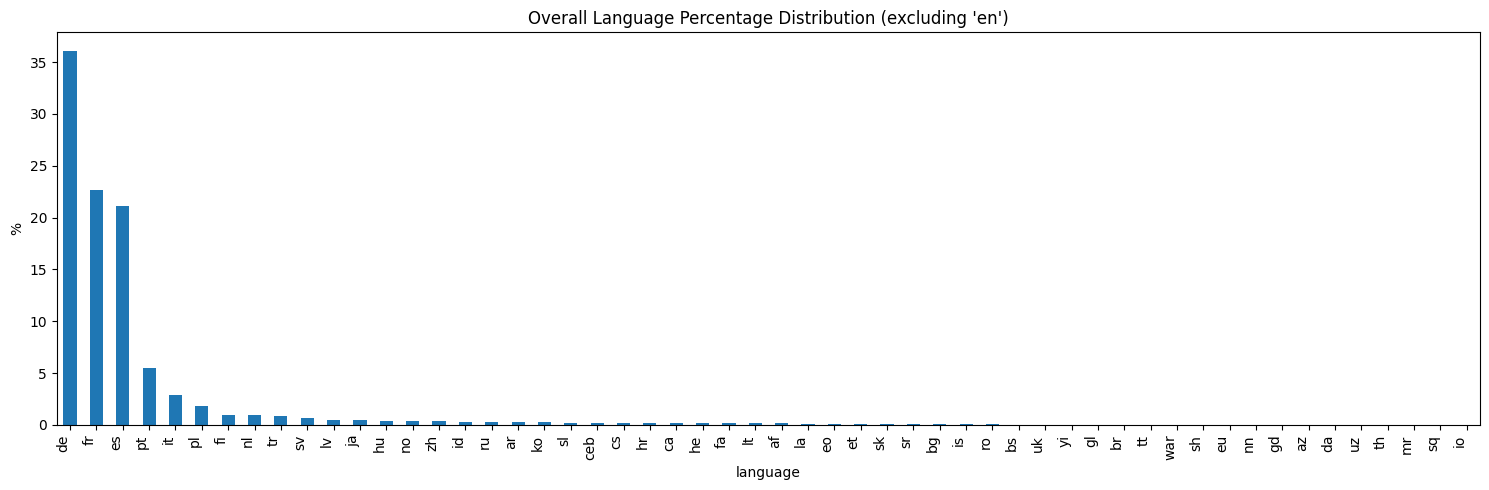

In [16]:
# Filter out English
df_no_en = big_df[big_df["language"] != "en"]

# Count languages per dataset
lang_counts_no_en = df_no_en.pivot_table(
    index="dataset_id",
    columns="language",
    aggfunc="size",
    fill_value=0
)

plt.figure(figsize=(15, 5))
(df_no_en["language"].value_counts(normalize=True) * 100).plot(kind="bar")

plt.ylabel("%")
plt.title("Overall Language Percentage Distribution (excluding 'en')")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

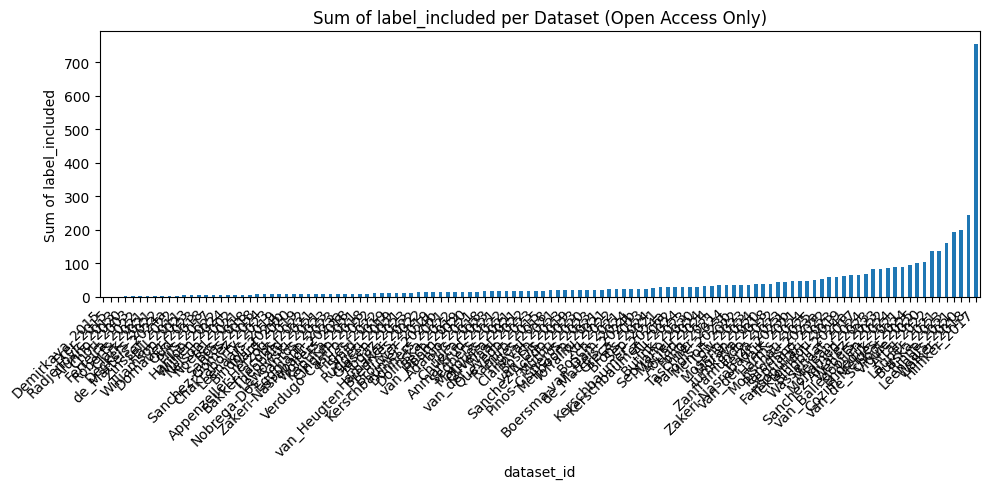

In [17]:
# 1. Filter to only open-access rows
df_oa = big_df[big_df["is_open_access"] == 1]

# 2. Sum label_included per dataset
included_sum = (
    df_oa.groupby("dataset_id")["label_included"]
    .sum()
    .sort_values()
)

# 3. Plot
plt.figure(figsize=(10, 5))
included_sum.plot(kind="bar")

plt.ylabel("Sum of label_included")
plt.title("Sum of label_included per Dataset (Open Access Only)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
for dataset_id, value in included_sum.items():
    print(dataset_id, value)

Demirkaya_2015 0
Erer_2015 0
Radjenovic_2013 0
Alunno_2020 1
Chou_2003 1
Ferreira_2022 3
Roberts_2021 3
Clark_2021 3
Deckers_2022 3
de_Matteis_2024a 3
Zinsser_2022 3
Hall_2011 4
Williamson_2023 5
Dornauer_2023 5
Oud_2018 5
Pijls_2017 5
Hanlon_2022 6
Wijnen_2024 6
Nelson_2002 6
Noetel_2021 6
Bos_2018 6
Santos_2018 7
Sanchez-Gomez_2024 7
Chakraborty_2023 7
Leenaars_2019 7
Bindoli_2024b 7
Ward_2020 8
Appenzeller-Herzog_2019 8
Bakker-Jacobs_2022 8
Theobald_2021 9
Lewowski_2021 9
Nobrega-Dos_Santos_2023 9
Eggmann_2023 9
Zakeri-Nasrabadi_2023a 9
Wolters_2018 9
Kapuka_2021 9
Cinquin_2018 9
Verdugo-Castro_2022 10
Filges_2022 10
Smid_2019 11
Ruggeri_2019 11
Giesen_2021 11
Abgaz_2023 12
Hamaker_2022 13
van_Heugten_Breurkes_2022 13
Brouwer_2019 14
Kerschbaumer_2024b 14
Donners_2021 15
Dolinska_2022 15
Bech_2019 15
van_Hoorn_2020 15
Adamo_2021 15
Pijls_2018 16
Chueca_2023 16
Anmarkrud_2021 16
Seghers_2022 16
Marques_2021 16
Oliveira_2021 17
van_der_Waal_2022 17
Quevedo_2023 18
Ramiro_2015 18
Filge

In [19]:
abstract_pct = big_df.groupby("dataset_id")["abstract"].apply(lambda x: x.notna().mean() * 100)
print(abstract_pct.mean())
abstract_pct.sort_values()

91.669634243975


dataset_id
Dornauer_2023              61.334868
Zakeri-Nasrabadi_2023a     62.306994
Wassenaar_2017             63.226917
Pijls_2017                 65.882353
Kapuka_2021                66.822430
                             ...    
Mejean_2024               100.000000
Anmarkrud_2021            100.000000
Ruggeri_2019              100.000000
Toffalini_2021            100.000000
Santos_2018               100.000000
Name: abstract, Length: 120, dtype: float64

<Axes: xlabel='dataset_id'>

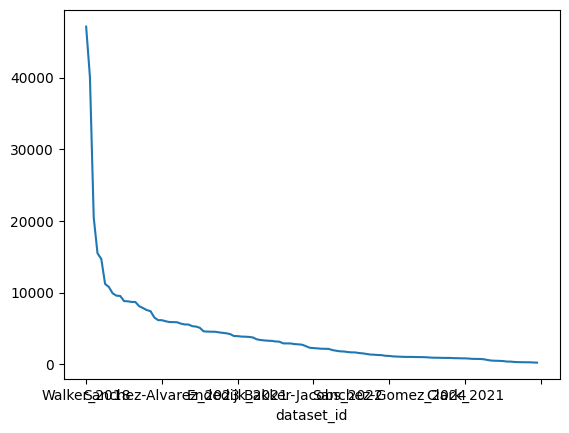

In [20]:
big_df.value_counts("dataset_id").plot()

In [21]:
# per dataset wel/niet open access 